In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict ,Annotated
from pydantic import BaseModel , Field
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import operator

c:\Users\Mushaf\Desktop\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class EvaluationScheama(BaseModel):
    feedback: str = Field(description = "Detaied feedback for the essay")
    score: int = Field(description = "Score out of 10" , ge=-1 , le=11)

In [4]:
structuralModel = model.with_structured_output(EvaluationScheama)

In [5]:
essay = f"""
The Importance of Education

Education is the foundation of a prosperous and progressive society. It empowers individuals with the knowledge, skills, and critical thinking needed to navigate the complexities of life. Through education, people gain awareness of their rights and responsibilities, develop a sense of ethics, and become capable of making informed decisions.

Moreover, education fuels innovation and economic growth. Societies that prioritize learning and research produce skilled professionals, thinkers, and leaders who drive technological advancements and social reforms. Education also promotes equality, providing opportunities for marginalized communities to uplift themselves and break the cycle of poverty.

In conclusion, education is not merely a pathway to employment; it is a transformative force that shapes character, broadens horizons, and fosters societal progress. Every individual, regardless of their background, deserves access to quality education to unlock their full potential and contribute meaningfully to the world.
"""


In [6]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10  \n {essay}"
structuralModel.invoke(prompt)

EvaluationScheama(feedback='The essay demonstrates excellent language quality. It is well-structured, uses clear and concise language, and employs a strong vocabulary to effectively convey its message. There are no grammatical errors or spelling mistakes, and the flow of ideas is very smooth. The arguments are presented logically and persuasively, making it a highly readable and impactful piece.', score=9)

In [21]:
class essayState(TypedDict , total=False):
    essay: str
    languageFeedback : str
    analysisFeedback : str
    thoughtFeedback : str
    overallFeedback : str
    individualScore: Annotated[list[int],operator.add]
    averageScore: float

In [22]:
def evaluateLanguage(state: essayState):
    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10  \n {essay}"
    evaluateLanguage = structuralModel.invoke(prompt)
    return {"languageFeedback" : evaluateLanguage.feedback , "individualScore" : [evaluateLanguage.score] } 

In [23]:
def evaluateAnalysis(state: essayState):
    prompt = f"Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10  \n {essay}"
    evaluateAnalysis = structuralModel.invoke(prompt)
    return {"analysisFeedback" : evaluateAnalysis.feedback , "individualScore" : [evaluateAnalysis.score] } 

In [24]:
def evaluateThoughts(state: essayState):
    prompt = f"Evaluate the depth of thought of the following essay and provide a feedback and assign a score out of 10  \n {essay}"
    evaluateThoughts = structuralModel.invoke(prompt)
    return {"thoughtFeedback" : evaluateThoughts.feedback , "individualScore" : [evaluateThoughts.score] } 

In [31]:
def finalAnalysis(state: essayState):
    a = state["analysisFeedback"]
    b= state["thoughtFeedback"]
    c = state["languageFeedback"]
    prompt = f"based on {a} , {b} , {c} , give a overall feedback for the essay  \n {essay}"
    overallFeedback = model.invoke(prompt)
    state["overallFeedback"] = overallFeedback
    averageScore = sum(state["individualScore"])/len(state["individualScore"])
    return {"overallFeedback": overallFeedback ,"averageScore" :  averageScore}

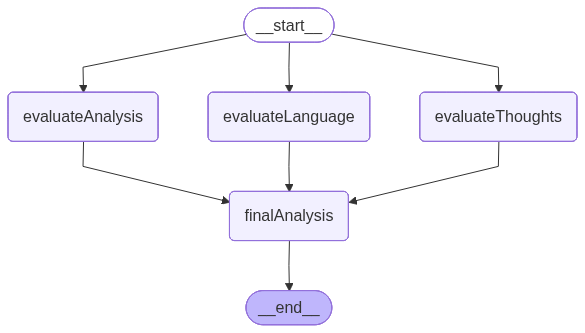

In [32]:
graph = StateGraph(essayState)

graph.add_node("evaluateLanguage" , evaluateLanguage)
graph.add_node("evaluateAnalysis" , evaluateAnalysis)
graph.add_node("evaluateThoughts" , evaluateThoughts)
graph.add_node("finalAnalysis" , finalAnalysis)

graph.add_edge(START, "evaluateLanguage")
graph.add_edge(START, "evaluateAnalysis")
graph.add_edge(START, "evaluateThoughts")

graph.add_edge("evaluateLanguage", "finalAnalysis")
graph.add_edge("evaluateAnalysis", "finalAnalysis")
graph.add_edge("evaluateThoughts", "finalAnalysis")

graph.add_edge("finalAnalysis", END)


graph.compile()

In [33]:
workflow = graph.compile()
initialState = {"essay" : essay}

finalState = workflow.invoke(initialState)



In [34]:
finalState

{'essay': '\nThe Importance of Education\n\nEducation is the foundation of a prosperous and progressive society. It empowers individuals with the knowledge, skills, and critical thinking needed to navigate the complexities of life. Through education, people gain awareness of their rights and responsibilities, develop a sense of ethics, and become capable of making informed decisions.\n\nMoreover, education fuels innovation and economic growth. Societies that prioritize learning and research produce skilled professionals, thinkers, and leaders who drive technological advancements and social reforms. Education also promotes equality, providing opportunities for marginalized communities to uplift themselves and break the cycle of poverty.\n\nIn conclusion, education is not merely a pathway to employment; it is a transformative force that shapes character, broadens horizons, and fosters societal progress. Every individual, regardless of their background, deserves access to quality educatio